# Import

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
import lmfit as lm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import vonmises
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter
from scipy.stats import gamma as gamma_dist
from scipy.special import iv as mod_bessel
from scipy.optimize import fsolve
from  scipy.ndimage import laplace  as laplace_fil
from scipy.special import gamma as gamma_func
import seaborn as sns
import matplotlib as mpl
import scipy.optimize as opt
import scipy.stats as stats
from scipy.signal import savgol_filter
import rdfpy
from circle_fit import taubinSVD
from circle_fit import lm as lm_fit
import traceback

mpl.rcParams['font.size']  = 18
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 17
pd.options.display.float_format = '{:,.4f}'.format

# Functions

## Simulate site

In [2]:
# function: Imaging: Input: x,y Output: SMLM locs
# Main photophysical parameters: 
#  - lab_prob  --> Label efficency 
#  - mu, sigma --> Blinking Prob. (Locs are generated from a LogNormal Dist. with pameters mu and sigma)
#    Mean[LogN(mu,sigma)] = exp [ mu + sigma^2/2 ]
#    Var[LogN(mu,sigma) ] = mean^2*(exp[sigma^2]-1)
#  - av_loc_noi--> Mean Poisson Noise

def estimate_logn_params_per_Mmample(locs_npc,f=0.55,n=16):
    # f --> label_efficiency
    #for nup188_dataset_3
    #  --> stats.lognorm.fit(locs_npc,floc=0) = (0.35174742475040593, 0.0, 47.42874625264248)
    ##   --> sigma_n = 0.35 mu_n = np.log(47.42) 
    ###   --> mu_Mmaple, sigma_Mmaple = (1.3636230978739285, 0.8772976587544037)
    
    sigma_n, loc, scale = stats.lognorm.fit(locs_npc,floc=0)
    mu_n  = np.log(scale)    
    
    sigma_Mmaple = np.sqrt(np.log(1+f*n*(np.exp(sigma_n**2)-1)))
    mu_Mmaple    = np.log(locs_npc.mean()) - sigma_Mmaple**2/2 -np.log(f*n)
    
    return (mu_Mmaple,sigma_Mmaple)
    ## This result in 

def imaging(nex,x_e,y_e,nsims=100):
    
    if nex==0:
        return([])    
    
    imsize   = 128
    pixelsize= 3
    ro       = 150 ## Radius used as ROI to define a site in SMAP

    #average of a poisson distrib to add sparse localization with uniform spatial distribution
    #Around 20 locs per 150nm X 150nm area (Extracted from experimental images, using non-GFP-colocalizing locs)    # 
    #
    av_loc_noi = 4.0    
    ## External Inputs
    """
    lab_prob   = 0.55   #labeling probability
    #geopar     = 0.125 #to get average of 8 locs per mol
    mu,sigma   = [1.50,0.85] """
    
    #Last analyisis of NPC_188 data, suggests a log-normal distribution of x = locs/mol
    # x ~ exp(-(logx - mu*)^2/2*sigma^2) with u* = np.exp(mu)  

    nprot_per_ex = 3; #number of proteins per exocyst
    min_d        = 1; #minimum distance between exocysts (nm) ## Not used

    err_pro  = 10; # std distance of protein from exocyst center (nm)
    loc_prec = 20/np.sqrt(2); #(nm)
    
    n = {}
    
    x_e = np.array(x_e)
    y_e = np.array(y_e)
    
    ## Additional error for the exocyst location --> Is it needed?
    rr_x = 0 
    rr_y = 0        
    
    x_er  = x_e + rr_x
    y_er  = y_e + rr_y
    
    data= []

    for i in range(nsims):

        pos     = []
        pos_noi = [] 
        
        n=0                   
        

        for j in range(nex): #for each exocyst, get its x and y pos

            x=x_er[j];
            y=y_er[j];

            for k in range(nprot_per_ex): #for each protein per exocyst, get its x and y pos respect to corresponding exocyst
                
                x_pro = x+np.random.normal(0,err_pro)
                y_pro = y+np.random.normal(0,err_pro)
               
                if np.random.rand()<lab_prob: # include finite labeling probability, not all proteins emit
                    #nn=np.random.geometric(geopar) # this is the number of localizations per protein
                    nn=stats.lognorm.rvs(s=sigma,scale=np.exp(mu)) # this is the number of localizations per protein
                    nn=int(np.round(nn))
                    n=n+nn
                    for l  in range(nn): #for each Mmaple generate nn blinking locs
                        x_locs=x_pro+np.random.normal(0,loc_prec)
                        y_locs=y_pro+np.random.normal(0,loc_prec)
                        pos.append([x_locs,y_locs])    
        
        pos = np.array(pos)
        
        # add sparse localizations for noise
        num_loc_noi = np.random.poisson(av_loc_noi);
        x_locs_noi  = np.random.uniform(-ro,ro, num_loc_noi)
        y_locs_noi  = np.random.uniform(-ro,ro, num_loc_noi)        
        
        ## 0 --> Loc  1 --> Noi
        lb = np.array([ 0 if i < len(pos) else 1 for i in range(len(pos)+num_loc_noi)])
        
        ## Generate Random localization precision
        ##  --> Experiments show a Uniform Distribution in the range(5-25)
        locp = np.random.uniform(5,25,size=len(lb))        
        
        if len(pos)>0:

            site_data = pd.DataFrame(data=[[i,nex,n,num_loc_noi,x_e,y_e,np.concatenate([pos[:,0],x_locs_noi]),
                                            np.concatenate([pos[:,1],y_locs_noi]),locp,lb]
                                          ],
                                   columns=["ID","N_Exos","N_Locs","N_Locs_noi","X_Exos","Y_Exos",
                                            "X_Locs","Y_Locs","LocP","Locs_ID"])
            if len(data) == 0:
                data = site_data
            else:
                data = pd.concat([data,site_data],ignore_index=True)
                
    return(data)


## Pathway

In [3]:
##  function: vesicle_shape_evolution   : Input: model,params,time Output: x_e's,y_e's

def vesicle_shape_evolution(model,params):
    angular = model["Angular"]
    radial  = model["Radial"]  
    copial  = model["Copy"]  
    ro    = params['ro']
    r1    = params['r1']    
    dro   = params['dro']
    dth   = params["dtheta"]
    #nex   = params['nex']
    #t     = params['t']#{'alpha':alpha,'t':t}
    
    if  copial == "Experimental" and ( "Exp_Nex" in params.keys()):  
        y   = params['Exp_Nex']
        nex = int(y(t))
    elif copial == "Fixed" and ( "Fixed_Nex" in params.keys()):          
        nex = int(params["Fixed_Nex"])
    else:
        nex = 3
    
    if  radial=="Fixed":
        r = ro  * np.ones(nex)    
    elif radial=="Random":
        r = np.sqrt(np.random.rand(nex)*(ro**2-r1**2)+r1**2) ## Random between the radii r1 and r0
    else:
        print("Not radial model selected")    
    
        #r   = np.ones(nexos)*ro   
    
    if angular =="Random":   
        
        th  = []
        pos = []
        rs  = []
        #exo_radii = 8 #nm --> Exocyst Effective Radii
        th0 =  np.random.rand()*2*np.pi
        
        for i in range(nex):
            if i ==0:
                th_aux = th0 + np.random.rand()*dth
                x_aux  = r[i]*np.cos(th_aux)
                y_aux  = r[i]*np.sin(th_aux)
                rs.append(r[i])
                th.append(th_aux)
                pos.append([x_aux,y_aux])
            else:
                d = False
                j = 0
                while(not d and j<10):
                    j += 1
                    #print("Try :%d"%j)
                    th_aux = th0 + np.random.rand()*dth
                    x_aux  = r[i]*np.cos(th_aux)
                    y_aux  = r[i]*np.sin(th_aux)                    
                    d      = np.all(np.linalg.norm(np.array(pos)-[x_aux,y_aux],axis=1)>2*exo_radii) 
                if d:
                    rs.append(r[i])
                    th.append(th_aux)
                    pos.append([x_aux,y_aux])  
    elif angular == "N_Fold":        
        #exo_radii = 8 #nm --> Exocyst Effective Radii
        th0 =  np.linspace(0,2*np.pi,nex+1)[:-1]  
        rs  =  r
        th  =  th0        
        
    if dro > 0:
        rs  = rs + np.random.uniform(-dro,dro,size=len(rs))
    x   = rs*np.cos(th)
    y   = rs*np.sin(th)
    return(r,x,y)
        
def time_profile_Experimental(t, nmax=15, beta=3, tau=4):
    return nmax*np.exp(-abs((t-5)/tau)**(2*beta))

def time_profile_Fixed(t,nmax):
    return nmax

def normal_radial(t,amp,mu,sigma):
    return amp*np.exp(-(t-mu)**2/2/sigma**2)
    
def rendering(xs,ys,sigma=8/np.sqrt(2),density=False):      
    drr=sigma // 2        
    hist,binsx,binsy=np.histogram2d(xs,ys,bins=np.arange(-150,151,3),density=density)
    img = gaussian_filter(hist, sigma=sigma/3)
    return(binsx,binsy,img)


## Geometrical features calculation

In [4]:
 
def p_intersect(p1,p2,u1,u2):
    t=u2[1]*(p1[0]-p2[0])-u2[0]*(p1[1]-p2[1])
    det=u1[1]*u2[0]-u1[0]*u2[1]
    if det == 0:
        p = (p1+p2)/2.
    #print(det)
    else:
        p=p1+t/det*u1
    
    return(p)

def rot_vect(v,theta):
    rot_Mat = np.array([[np.cos(theta),np.sin(theta)],[-np.sin(theta),np.cos(theta)]])
    vrot= rot_Mat.dot(v)
    return(vrot)

def PCA_center_workflow(data,do_Least_Squares):
    ## ----------------------------###
    # 1) PCA all data  --  Output: {mean_all, V_all}
    # 2) Rotated and Traslate data using V2  -- Output: {data_T}
    # 3) PCA symmetrized all data -- Output: {mean_sym,V_sym}
    # 4) Calculate 0-th center as the intersection of lines {mean_all,V_all},{mean_sym,V_sym} -- Output: {cx_sym,cy_sym}
    # If do_Least_Squares: 
    # 5) Choose subset of locs from data_T with y > yo with yo = minY+ (maxY-minY)/10*i, i=1,2,3, ... Output : {data_T_k}    
    # 6) Calculate PCA over data_T_k: --- output: {mean_k, V_k}
    # 7) Resolve the minimization problem [cx_LS,cy_LS] = min(x,y) sum_k w_k Distance(L_k,mean_k) --- Output: cx_Ls,cy_Ls
     ## ----------------------------###
    
    dist = np.linalg.norm(data,axis=1)
    data = data[dist<150]
    ######---PCA all-data ----######
    #-------------------------#
    pca    = PCA(n_components=2)
    data_T = pca.fit_transform(data)
    vect   = pca.components_        
    ratio  = pca.explained_variance_ratio_[0]
    nv     = 1
    #-------------------------#    
    
    ######---PCA symmetrized all-data ----######
    #-------------------------#
    theta      = np.arctan(vect[nv,1]/vect[nv,0])
    data_T     = data -np.mean(data,axis=0)
    data_T     = np.apply_along_axis(rot_vect,1,data_T,theta)
    data_T[:,1]= abs(data_T[:,1])
    data_T     = np.apply_along_axis(rot_vect,1,data_T,-theta)
    
    data2      = data_T + np.mean(data,axis=0)    
    data2_T    = pca.fit_transform(data2)
    vect2      = pca.components_
    nv2        = 1 
    #nv2 = choose_pca_axes(data2,vect2,False)
    #-------------------------#    

    p1=np.mean(data,axis=0)
    p2=np.mean(data2,axis=0)
    p=p_intersect(p1,p2,vect[nv],vect2[nv2])   
    return(p,theta,ratio)
    
def calculate_PCA_params_per_site(data_input,idf,ids):    
   
    
    rmax   = 120 # nm --Max Radius to calculate radial density 
    alpha  = 1.5 # Chosen points are inside alpha*R    
    do_PCA = True    
    
    site_params = []
    #Load Data
    x       =  data_input.loc[(data_input["FILE_ID"]==idf)&(data_input["Site_ID"]==ids),"X_Locs"].values[0]
    y       =  data_input.loc[(data_input["FILE_ID"]==idf)&(data_input["Site_ID"]==ids),"Y_Locs"].values[0]
    locp    =  data_input.loc[(data_input["FILE_ID"]==idf)&(data_input["Site_ID"]==ids),"LocP"].values[0]

    dist    =  x**2+y**2
    ro      =  150 # The same  value is used in Matlab to extract the locs from experimental data
    x       =  x[dist<ro**2]
    y       =  y[dist<ro**2]
    locp    =  locp[dist<ro**2]

    data_or = np.stack((x,y),axis=1)    
    

    n       = len(data_or)
    nlocsG,nlocsUG = [n,0]
    GFP_pos = [0,0]    
    
    ##-----------------------------------------------------------------------------------------------##
    ## Calculate copy number 
    nexos = data_input.loc[(data_input["FILE_ID"]==idf)&(data_input["Site_ID"]==ids),"N_Exos"].values[0]
    ##-----------------------------------------------------------------------------------------------##
    
    if n>10:
        data = np.copy(data_or)
        #print(idf,s)            

        ##-------Calculate center-------
            ## First approximation : Center of mass
        CM_pos_Raw = np.mean(data,axis=0)
        dist = np.linalg.norm(data-CM_pos_Raw,axis=1)
        R = np.sqrt(np.mean(dist**2))   
        R = 1.4 * R
        data = data[dist <= alpha*R]
        locp = locp[dist <= alpha*R]
        R_raw= R
            ## Second approximation : Center of mass of points inside the previous R
        if len(data)>0 :
            CM_pos = np.mean(data,axis=0)
            dist = np.linalg.norm(data-CM_pos,axis=1)
            R = np.sqrt(np.mean(dist**2))  
            R = 1.4*R
            data = data[dist <= alpha*R]      
            locp = locp[dist <= alpha*R]
            R_2nd= R

        if len(data)>0 : 
            if do_PCA:
                    ## Third approximation : PCA_center of points inside the previous R
                    ##-------------------------   
                    [cx,cy], theta, ratio = PCA_center_workflow(data , False)               

                    dist = np.linalg.norm(data-[cx,cy],axis=1)
                    R = np.sqrt(np.mean(dist**2))        
                    R = 1.4*R
                    R_PCA = R                    
                    d_CM_PCA=np.linalg.norm(CM_pos-[cx,cy])                    
                    ##-------------------------   
            else:
                cx,cy = CM_pos
                theta = 0.0
                ratio = 0.0
                R_PCA = R_Raw
                d_CM_PCA=np.linalg.norm(CM_pos-CM_pos_Raw)                    
        else:
                cx,cy = CM_pos
                theta = 0.0
                ratio = 0.0
                R_PCA = R_Raw
                d_CM_PCA=np.linalg.norm(CM_pos-CM_pos_Raw) 
                

        ## Calculate radial_distribution        
        dist  = np.linalg.norm(data-CM_pos,axis=1)
        den   = dist                    
        data_T= np.apply_along_axis(rot_vect,1,data-CM_pos,theta)
        ang   = np.arctan2(data_T[:,1],data_T[:,0])
        
        ## Calculate Weighted-R2
        dist = np.linalg.norm(data-[cx,cy],axis=1)
        w_i  = (1/locp**2)        
        R_w  = np.sqrt(np.sum(w_i*dist**2)/np.sum(w_i)) 
        
        site_params.append([idf,ids,len(data_T),theta,ratio,R_raw,R_2nd,
                            R_PCA,R_w,den,ang,d_CM_PCA,GFP_pos[0],GFP_pos[1],CM_pos[0],CM_pos[1],cx,cy,nlocsG,nlocsUG,nexos])        
        site_params = pd.DataFrame(data=site_params,columns=["File_ID","Site_ID","N_Locs","PCA_Theta","PCA_Ratio","R_Raw","R_2nd","R_PCA",
                                                             "R_w","Radial_Coords","Angular_Coords","GFP_Distance",
                                                            "GFP_Center_X","GFP_Center_Y","Mass_Center_X","Mass_Center_Y","PCA_Center_X",
                                                             "PCA_Center_Y","Nt_Locs_Gr","Nt_Locs_UnGr","Nexos"])
 
    return (site_params)

def gamma(x,a,b,c):
    return(c*x**a*np.exp(-b*x))

def fitting_per_site(site_params,do_angular_fitting=False):  
    
    den    = site_params["Radial_Coords"].values[0]
    ang    = site_params["Angular_Coords"].values[0]
    #print(den)
    a,b,c,m_val = [1,1,1,1]
    
    gmodel = lm.Model(gamma)
        
    den,rpoints = np.histogram(den,bins=np.arange(0,150,10))        
    xx=rpoints[:-1]
    xx=xx + np.diff(xx)[0]*0.5#/max(rpoints)
    #xx=xx[:-1]+np.diff(xx)[0]/2
    n=np.sum(den)
    
    params = lm.Parameters()
    params['a'] = lm.Parameter(name='a', value=0.1*np.mean(den)+1, min=-1,vary=True)
    params['b'] = lm.Parameter(name='b', value=0.1, min=0,vary=True)
    params['c'] = lm.Parameter(name='c', value=0.1, min=0,vary=True)
        
    if n > 0:
        ## Radial fitting --> Gamma Dist.
        yy=den/n*np.diff(xx)[0]
        #print(s,xx,yy)

        result = gmodel.fit(yy, x=xx,params=params) 
        a = result.values["a"]
        b = result.values["b"]
        c = result.values["c"]
        ns= n

        ##Angular fitting --> GVMD Dist.          
        if do_angular_fitting:
            try:
                # block raising an exception
                m = vonmises_mix.mixture_pdfit(ang,n=2)                
            except:
                print("The angular fitting could not be done")
                m = np.zeros(6)
                pass # doing nothing on exception
            m_val = m.flatten()
        else:
            m_val = 0
    
    a = a+1
    b = b+1
    c = c        
    
    site_params["Radial_Fit_Params"] = [[a,b,c]]                                        
    site_params["Angular_Fit_Params"] = [m_val]
        
    return(site_params)

##Fix rmin calculated from scatter points, taking account the error in the localization
##--> Suppose we have an point located at a distance=rmin, then, a gaussian intensity with N(rmin,sigma)
## is calculated. The radial distribution of the intensity is given by: 
## f(r)=r/sigma**2 * Jo(r*rmin/sigma**2)*exp(-(r**2-rmin**2)/2*sigma**2) 
## For r*R/sigma**2 << 1, this can be approximated as 
## f(r)= r/sigma**2**exp(-(r**2-rmin**2)/2sigma**2 --> proportional to Rayleigh Distribution
## The CDF is given by ~   exp(-rmin**2)-exp(-(r**2-rmin**2)/2*sigma**2)
## Defining the radius minimum as CDF(ro)==epsilon
## ro = sqrt(2*sigma**2*Log(1/(1-epsilon)-R**2))
def rmin_Rayleigh_dist(rmin,epsilon,sigma):
    arg=2*sigma**2*np.log(1/(1-epsilon))-rmin**2
    if arg < 0:
        return(rmin)
    else:
        return( np.sqrt(arg))

def radial_gaussian(xy,ro,sigma,amplitude,xo,yo):
    if len(np.shape(xy))!=1:
        x, y = xy    
        r = np.sqrt((x-xo)**2+(y-yo)**2)   
    else:
        r = np.abs(xy-xo)      
    #sigma = 15.
    g  = amplitude*np.exp(-(r-ro)**2/(2*sigma**2))
        
    return g.ravel()

def fitting_workflow(site_params,data_input):

    aux_params = site_params.copy()
    
    #aux_params["Tau_Center"] = aux_params["File_ID"].astype('object')
    #aux_params["LM_Center"]  = aux_params["File_ID"].astype('object')        
    
    sigma=8/np.sqrt(2)
    drr=sigma // 2
    
    for j,id in enumerate(aux_params.index):        
        
        idf = aux_params.loc[id,"File_ID"]
        ids = aux_params.loc[id,"Site_ID"]
        R   = aux_params.loc[id,"R_Raw"]
        
        data_or = data_input.loc[(data_input["FILE_ID"]==idf)&(data_input["Site_ID"]==ids),
                                 ["X_Locs","Y_Locs"]].values        
        
        GFP_cx =  aux_params.loc[id,"GFP_Center_X"]  ##GFP center        
        GFP_cy =  aux_params.loc[id,"GFP_Center_Y"]  ##GFP center        
        cx =  aux_params.loc[id,"Mass_Center_X"]         ##Mass center    
        cy =  aux_params.loc[id,"Mass_Center_Y"]         ##Mass center    
        theta =  aux_params.loc[id,"PCA_Theta"]          
        
        data_or = np.stack((data_or[0,0],data_or[0,1]),axis=1)
        data_or = data_or -[cx,cy]               
        dist    = np.linalg.norm(data_or,axis=1)
        data_or = data_or[dist<1.4*R]
        
        ## Taubin Fitting
        ## --------------------------------------------------------------------------------------------##        
        try:
            xc, yc, r_tau, sigma_tau = taubinSVD(data_or)
        except:
            print("Using GFP center for Tau_Center")
            xc, yc, r_tau, sigma_tau = [GFP_cx,GFP_cy,-1,-1]                                               
        
        aux_params.loc[id,"R_Tau"]      = r_tau
        aux_params.loc[id,"Sigma_Tau"]  = sigma_tau
        aux_params.loc[id,"Tau_Center_X"]  = xc
        aux_params.loc[id,"Tau_Center_Y"]  = yc
        aux_params.loc[id,"Tau_Shift"]  = np.sqrt(xc**2+yc**2)        
        ## --------------------------------------------------------------------------------------------##
        ## LM Fitting
        ## --------------------------------------------------------------------------------------------##        
        try:
            xc, yc, r_lm, sigma_lm = lm_fit(data_or,par_ini=[xc,yc,r_tau])
        except:
            print("Using GFP center for LM_Center")
            xc, yc, r_lm, sigma_lm = [GFP_cx,GFP_cy,-1,-1]                                               
        
        aux_params.loc[id,"R_LM"]      = r_lm
        aux_params.loc[id,"Sigma_LM"]  = sigma_lm
        aux_params.loc[id,"LM_Center_X"]  = xc
        aux_params.loc[id,"LM_Center_Y"]  = yc
        aux_params.loc[id,"LM_Shift"]  = np.sqrt(xc**2+yc**2)
    
        
    return(aux_params)
    

def calculate_per_site_parameters(site_params,data_input,do_angular_fitting=False):
    
    epsilon= 0.05
    sigma  = 8
    params = [] 
    idf    = site_params["File_ID"].values[0]
    ids    = site_params["Site_ID"].values[0]   
    R      = site_params["R_Raw"].values[0]           
    
    data_or = data_input.loc[(data_input["FILE_ID"]==idf)&(data_input["Site_ID"]==ids),
                                 ["X_Locs","Y_Locs"]].values  
    data_or = np.stack((data_or[0,0],data_or[0,1]),axis=1)
    
    cx = site_params["Mass_Center_X"].values[0]        #Mass center
    cy = site_params["Mass_Center_Y"].values[0]        #Mass center
    GFP_cx = site_params["GFP_Center_X"].values[0] #GFP center     
    GFP_cy = site_params["GFP_Center_Y"].values[0] #GFP center     
    ##-----------------------------------------------------------------------------------------------##

    ##-----------------------------------------------------------------------------------------------##
    for do_center in ["Mass_Center","Tau_Center"]:
        ##-----------------------------------------------------------------------------------------------##
        fx = site_params[do_center+"_X"].values[0]            #Chosen center
        fy = site_params[do_center+"_Y"].values[0]            #Chosen center

        
        if do_center in ["Tau_Center","LM_Center"]:            
            fx,fy = [fx+cx,fy+cy]                
        
        if not do_center in ["Tau_Center","LM_Center",
                             "Mass_Center","PCA_Center","GFP_Center"]:            
            print("Please,Specify the center\nUsing GFP_Center")
            fx,fy = [GFP_cx,GFP_cy]          

        den = np.linalg.norm(data_or-[fx,fy],axis=1)
        ang = np.arctan2(data_or[:,1]-fy,data_or[:,0]-fx)        
             
        site_params.at[0,"Radial_Coords"]  = den 
        site_params.at[0,"Angular_Coords"] = ang                
        
        ##-----------------------------------------------------------------------------------------------##
        ## Perform fitting ##
        site_params = fitting_per_site(site_params)
        if do_center == "Mass_Center":
            site_params = fitting_workflow(site_params,data_input)         
        ##-----------------------------------------------------------------------------------------------##

        ##-----------------------------------------------------------------------------------------------##
        ## Calculate inner_radius ##
        [alpha,b,c] = site_params["Radial_Fit_Params"].values[0]
        #alpha## This alpha value correspond to X^(a-1)*Exp(-b*x) standard form of the gamma function
        ## If we add -1 :-> alpha=radial_fit[ids,0] - 1 :-> We obtained the radial density
        b     = b-1 ## This is done because we save np.array(b_val) + 1 in order to have the same script for the betta function
        rmin  = gamma_dist.isf(1-epsilon,alpha,scale=1/b)  
        rmin_corrected=rmin_Rayleigh_dist(rmin,epsilon,sigma)
        rmin  = rmin_corrected 
        #print(do_center,alpha,b,c,[fx,fy])
        ##-----------------------------------------------------------------------------------------------##

        ##-----------------------------------------------------------------------------------------------##
        ## Calculate angular parameters ##  
        # Zn = (1/N*sum_i=1,N (z_i)) where z_i = x/sqrt(x²+y²) + iy/sqrt(x²+y²)
        # z1 = Norm(Z1): First angular moment: 
        # z2 = Norm(Z2): Second angular moment
        # Ang:  Arg{Z1}: Mean angle
        # Varx, Vary: Variance of x/sqrt(x²+y²) and y/sqrt(x²+y²) rotated-coordinates         

        x    = np.cos(ang)
        y    = np.sin(ang)     
        z    = x + y*1j
        z1   = np.mean(z)
        z2   = np.mean(z**2)
        varx = np.var(x)
        vary = np.var(y)

        dr= 15
        if do_center == "GFP_Center":
            r = site_params["Rv"].values[0]  
            s = 15            
        elif do_center == "Tau_Center":
            r = site_params["R_Tau"].values[0]  
            s = site_params["Sigma_Tau"].values[0]  
        elif do_center == "Mass_Center":            
            r = site_params["R_2nd"].values[0]/1.4  
            s = 15            
        if r < 15:
            r = r + s            
        freq,bins = np.histogram(ang[abs(den-r)<dr],bins=np.arange(-1,1+1/8,1/8)*np.pi)
        freq = savgol_filter(freq,4,3)
        fill_factor = (len(freq[freq>1.5])/len(freq))

        mean_angle  = np.angle(z1) ## Arg{z1}        
        ##-----------------------------------------------------------------------------------------------##

        
        features = ["Inner_Radius","z1","z2","varX","varY","Mean_Angle","Fill_Factor","Ratio_Var"]
        center   = do_center.split("_")[0]
        
        if do_center != "Mass_Center":
            features = [ f + "_" +center for f in features]

        site_params[features] = [rmin,np.absolute(z1),
                       np.absolute(z2),varx,vary,mean_angle,fill_factor,vary/varx]            
        
    
    site_params["Other"] = 1   
    
    
    return(site_params)



class processing:
    
    def __init__(self,sites):              
        self.sites   = sites
        self.nsites  = len(sites)
        self.name    = "Exp_Path"
        self.params  = []
        self.do_ang_fit = False
        
    def run(self):
        
        columns = ['File_ID', 'Site_ID','Label','N_Locs','R_Raw','R_2nd','R_PCA','R_w',       
       'GFP_Distance','Nt_Locs_Gr', 'PCA_Ratio','PCA_Theta', 'PCA_Center_X','PCA_Center_Y',
                   'GFP_Center_X','GFP_Center_Y','Mass_Center_X','Mass_Center_Y','Fill_Factor',
                   'Ratio_Var', "Nexos","Inner_Radius","z1","z2","varX","varY",
                  "Mean_Angle","R_Tau","Sigma_Tau","Tau_Center_X",'Tau_Center_Y',"Tau_Shift",
                 "R_LM","Sigma_LM","LM_Center_X",'LM_Center_Y',"LM_Shift",
                 "Inner_Radius_Tau","z1_Tau","z2_Tau","varX_Tau","varY_Tau",
                 "Mean_Angle_Tau","Fill_Factor_Tau","Ratio_Var_Tau"]
        idss = self.sites[["FILE_ID","Site_ID"]].values
        #idMs = self.sites["GT"].unique()
        for j,ids in enumerate(self.sites[["FILE_ID","Site_ID"]].values):
            idf,ids = ids            
            self.site_params = []
            self.site_params = calculate_PCA_params_per_site(self.sites,idf,ids)
            #print(self.site_params)
            #print(idf,ids)
            if len(self.site_params) > 0:                    
                self.site_params["Label"] = self.name
                self.site_params = fitting_per_site(self.site_params)
                self.site_params = calculate_per_site_parameters(self.site_params,self.sites)
                if len(self.params) == 0:
                    self.params = self.site_params[columns]
                else:
                    self.params = pd.concat([self.params,self.site_params[columns]],ignore_index=True)
                    #self.params = pd.concat([self.params,self.site_params],ignore_index=True)                        
            else:
                continue           

# Running

In [5]:
"""data , params_simul = simulate_site()
xs = np.arange(0,10,0.1)
ys = ro+8*np.exp(-(xs-7)**2/2/1**2)
plt.plot(xs,ys)

model = {"Angular":"Random","Radial":"Normal","Copy":"Experimental"}
params= {"ro":20,"amplitude":8,"mu": 7, "sigma":1,"Exp_Nex":time_profile }
x,y =  vesicle_shape_evolution(model,params,.4)

ro = 20
th = np.linspace(0,2*np.pi,50)
xs = ro*np.cos(th)
ys = ro*np.sin(th)

plt.figure(figsize=(5*3,5*3))
for i,t in enumerate(np.arange(0,10,.5)):
    x,y =  vesicle_shape_evolution(model,params,t)
    plt.subplot(5,5,i+1)
    plt.scatter(x,y)
    plt.plot(xs,ys)
    
cmap = mpl.colors.LinearSegmentedColormap.from_list("", ["black","red"])"""
print("Test")

Test


## Generate Data

In [6]:
alldata = []
exo_radii = 6.5

#-----------------------------------------------------------------------
##These KEY parameters will be used for the "imaging" function
# The #-locs probability per mMaple is modeled as a log-normal distribution defined by parameters mu and sigma -> logN(mu,sigma)
# mu and sigma are estimated from the locs distribution from the reference Nup188 dataset 
lab_prob = 0.55
locs_npc = np.loadtxt("../Data/NPC_counting/locs_NPC_dataset_3.dat")[:,0]
mu,sigma = estimate_logn_params_per_Mmample(locs_npc,f=lab_prob)
#-----------------------------------------------------------------------
# loop over angular model [Random, N_Fold]
#    loop over number of exocysts
#       loop over radius of rings 
#          Generate position of exocysts <- vesicle_shape_evolution(model,params)
#          Generate position of locs     <- imaging(nex,x,y,1)

#-----------------------------------------------------------------------
# model dict is defined by  "Angular": {Random,N_Fold}, "Radial": {Fixed, Random} , "Copy": {"Fixed","Random"}
# params dict = {
# "ro": float, <- maximum radius
# "r1": float <ro <- minimum radius
# "Fixed_Nex": int <- max_exocysts copy number,
# "dro": float <- random error to the radius: r = r + random.uniform(-dro,dro)
# "dtheta": float in [0,2pi] <- Maximum angle where exocysts are distribuited 
# }

#-----------------------------------------------------------------------

for idm, m in enumerate(["Random","N_Fold"]):
    print("Running: " ,m)
    for idn,max_nex  in enumerate(range(6,7)): 
        for idr,ro in enumerate(np.random.uniform(15,20,10)):                    
            
            model = {"Angular":m,"Radial":"Fixed","Copy":"Fixed"}
            r1 = 0            
            params= {"ro":ro,"r1":r1,"Fixed_Nex":max_nex,"dro":0,"dtheta":2*np.pi}            
            
            aux= []                        
            r,x,y =  vesicle_shape_evolution(model,params)        

            nex  = len(x)  
            data = imaging(nex,x,y,1)    

            if len(data)==0 or nex<max_nex-2:
                continue
            else:                    
                data["Radius"] = r.mean()                     
                if len(aux) == 0:
                    aux = data.copy()
                else:            
                    aux = pd.concat([aux,data],ignore_index=True)             
                #print(nex)             
            if len(aux)>0:
                #print(100*(idm+1) + 10*(idn+1) + (idr+1))
                aux["FILE_ID"] = "Ring_%s_MaxExos_%d_Rv_%d"%(m,max_nex,ro//5)
                aux["Rv"]      = ro
                aux["Rv1"]     = r1
                aux["Max_Exos"]= max_nex
                aux["Site_ID"] = idr
                aux["GT"]      = m
                alldata.append(aux)
alldata = pd.concat(alldata,ignore_index=True)


Running:  Random
Running:  N_Fold


In [7]:
alldata

,ID,N_Exos,N_Locs,N_Locs_noi,X_Exos,Y_Exos,X_Locs,Y_Locs,LocP,Locs_ID,Radius,FILE_ID,Rv,Rv1,Max_Exos,Site_ID,GT
0,0,6,65,1,"[16.141380122320427, -9.140915294664794, -1.95...","[-1.0206540870021932, -13.342771623404131, 16....","[-20.34906951034114, -12.988986772789044, 7.71...","[22.03088215549082, 12.842680524734092, -34.32...","[11.349788153256563, 14.84079142403605, 20.385...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",16.1736,Ring_Random_MaxExos_6_Rv_3,16.1736,0,6,0,Random
1,0,5,110,3,"[-7.203454696564295, 0.3104055883030276, 9.824...","[-13.817182284645304, 15.579086437378812, -12....","[-24.97251479585757, -42.842596480456216, -46....","[-71.60098777741122, -40.3417677250757, -39.38...","[8.414060730538925, 5.285508196423148, 7.99171...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",15.5822,Ring_Random_MaxExos_6_Rv_3,15.5822,0,6,1,Random
2,0,6,46,8,"[8.377875782571229, -4.482564683873279, 11.509...","[-15.307156938623521, 16.864295716890634, 13.1...","[-3.102749046733662, 9.982048147797496, -11.12...","[-5.781352794587585, 13.168968987581266, -20.6...","[6.3620207762701675, 17.76980418069341, 15.701...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",17.4499,Ring_Random_MaxExos_6_Rv_3,17.4499,0,6,2,Random
3,0,5,51,5,"[4.976918922007309, 13.43286616291129, 2.54419...","[-14.975280717429962, 8.281718491435031, 15.57...","[-14.648992485425591, 9.929811579986701, -14.2...","[-22.104794037801216, 4.231441535028576, 32.38...","[10.924707102856114, 5.165668182787062, 23.118...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",15.7806,Ring_Random_MaxExos_6_Rv_3,15.7806,0,6,3,Random
4,0,5,51,2,"[8.908792695174274, -10.066955459372986, -16.5...","[-13.9627468923037, 13.152235393389505, 0.1805...","[15.715121545139196, 31.459816413578714, -5.74...","[19.441686688279944, 4.486219414904868, 27.158...","[17.939805282428402, 17.644361843031472, 6.873...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",16.5628,Ring_Random_MaxExos_6_Rv_3,16.5628,0,6,4,Random
5,0,5,65,7,"[-13.446509432341943, 12.577350869466818, -5.9...","[-8.165300761103738, -9.44939138461649, 14.574...","[-27.757136022755333, 1.272156329522936, -22.7...","[-42.26799683796567, -29.622387661024604, -19....","[10.61447458325885, 17.030467284864617, 9.8168...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",15.7315,Ring_Random_MaxExos_6_Rv_3,15.7315,0,6,5,Random
6,0,4,59,7,"[-0.7276344301455882, -14.936196501690953, 4.4...","[-15.16625450592839, 2.730340943069465, 14.529...","[-3.1422110849291243, -7.664064102707332, 10.3...","[-12.804954452579405, 1.2952804346134674, -4.5...","[18.019984472923234, 16.27236684682599, 23.711...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",15.1837,Ring_Random_MaxExos_6_Rv_3,15.1837,0,6,6,Random
7,0,4,37,5,"[6.442781645832124, -6.447691280361113, 14.209...","[13.835921406571211, -13.833634145004776, -5.5...","[31.77448633833218, 29.289715937301732, 24.444...","[41.00738691989045, 27.582903189344833, -11.36...","[18.377185259542664, 22.737308435388513, 13.61...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",15.2624,Ring_Random_MaxExos_6_Rv_3,15.2624,0,6,7,Random
8,0,5,46,5,"[1.9807932714681604, 4.2163563487329005, -11.0...","[-15.583498876987608, 15.132459098701286, 11.1...","[8.429578061296729, 11.909495529646986, 14.889...","[-27.13055136181905, -31.989608959679515, -21....","[11.016955482652657, 11.512910791989608, 14.30...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",15.7089,Ring_Random_MaxExos_6_Rv_3,15.7089,0,6,8,Random
9,0,5,58,4,"[12.046942580138765, -3.09852352574903, 17.782...","[-13.500635786247807, 17.826809701190374, 3.34...","[7.913731448371877, -5.170266340705158, 3.9644...","[3.8055537456936346, -19.61286930480901, -13.6...","[20.398169026272164, 20.488230764527806, 7.793...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",18.0941,Ring_Random_MaxExos_6_Rv_3,18.0941,0,6,9,Random


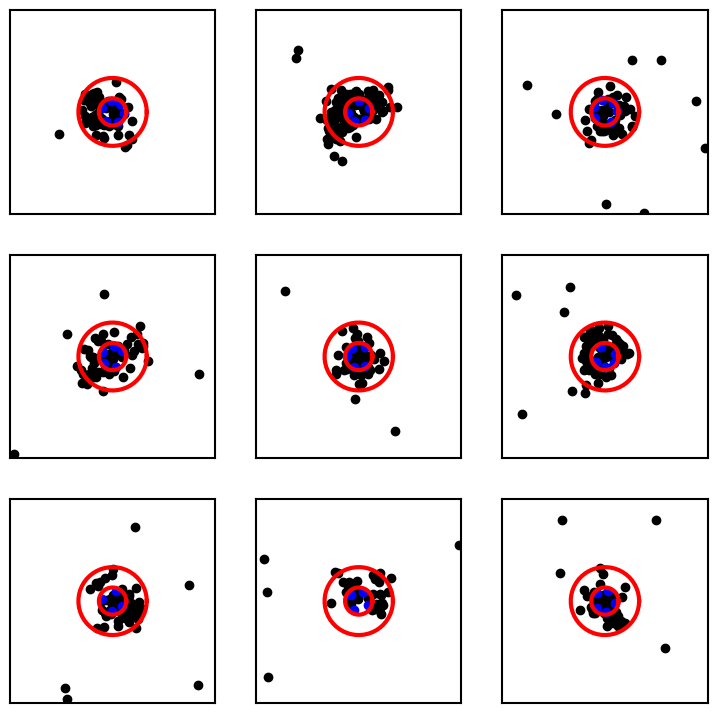

In [8]:
# Representative mosaic of simulated sites

ids = np.random.randint(len(alldata))
fig,axes = plt.subplots(3,3,figsize=(3*3,3*3))
axes  = np.ravel(axes)
for ids in range(len(alldata)):
    if ids < 9:
        ax = axes[ids]
        for i,j in enumerate(["Locs","Exos"]):
            x = alldata.iloc[ids:ids+1]["X_"+j]
            x = [ xxx for xx in x for xxx in xx ]
            y = alldata.iloc[ids:ids+1]["Y_"+j]
            y = [ yyy for yy in y for yyy in yy ]

            ro = 35-15
            r1 = 35+15
            th = np.linspace(0,1,50)*2*np.pi
            ax.scatter(x,y,color=['k','b'][i])        
        
        ax.plot(r1*np.cos(th),r1*np.sin(th),lw=3,color='r')
        ax.plot(ro*np.cos(th),ro*np.sin(th),lw=3,color='r')
        ax.set_xlim(-150,150)
        ax.set_ylim(-150,150)
        ax.set_xticks([])
        ax.set_yticks([])

In [9]:
# The geometrical features are computed for all the simulated sites.
#A parallel loop is used to speed up this step
from multiprocess import Pool
from tqdm import tqdm

def run(idf):
    
    workflow = processing(alldata.query("FILE_ID=='%s'"%idf))
    workflow.run()
    geom_params = workflow.params
    for idx in geom_params.index:
        ids = geom_params.loc[idx,"Site_ID"]
        idf = geom_params.loc[idx,"File_ID"]
        rv  = alldata.query("FILE_ID == '%s' and Site_ID == @ids" %idf)["Radius"].values
        gt  = alldata.query("FILE_ID == '%s' and Site_ID == @ids" %idf)["GT"].values
        n   = alldata.query("FILE_ID == '%s' and Site_ID == @ids" %idf)["Max_Exos"].values
        geom_params.loc[idx,"GT"] = gt
        geom_params.loc[idx,"Rv"] = rv
        geom_params.loc[idx,"Max_Exos"]   = n
    geom_params.to_csv("../Data/Geom_params_data_Simulate_%s.csv"%idf)

idfs = alldata["FILE_ID"].unique()

frames_list = idfs
max_pool = 30

with Pool(max_pool) as p:
    pool_outputs = list(
        tqdm(
            p.imap(run,
                   frames_list),
            total=len(frames_list)
        )
    )    

print(pool_outputs)

100%|██████████| 2/2 [00:00<00:00,  3.42it/s]

[None, None]


In [10]:
geom_params = pd.concat([pd.read_csv("../Data/Geom_params_data_Simulate_%s.csv"%idf) for idf in idfs],ignore_index=True)